In [45]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report


In [19]:
#Verileri oku

df_a = pd.read_excel("/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_A.xls", header=None)
df_b = pd.read_excel("/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_B.xls", header=None)
df_c = pd.read_excel("/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_C.xls", header=None)


print("A:", df_a.shape)

A: (4800, 200)


In [20]:
#normalization function

def normalize_samplewise(X):
    return (X - X.min(axis=1, keepdims=True)) / (
        X.max(axis=1, keepdims=True) - X.min(axis=1, keepdims=True) + 1e-8
    )

X_a = df_a.values.reshape(-1, 200, 1)
X_b = df_b.values.reshape(-1, 200, 1)
X_c = df_c.values.reshape(-1, 200, 1)

X_combined = np.concatenate([X_a, X_b, X_c], axis=2)

X_combined = normalize_samplewise(X_combined)

labels = np.repeat(np.arange(16), 300)

print("Final shape:", X_combined.shape)

Final shape: (4800, 200, 3)


In [39]:
#Train/Test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", X_train.shape)

Train: (3840, 200, 3)


In [40]:
#model architecture


def build_model(input_shape):
    model = Sequential([
        Conv1D(64, 3, activation='relu', kernel_regularizer=l2(0.001)),
        MaxPooling1D(2),
        Dropout(0.2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        LSTM(128),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(16, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [41]:
def augment_csi(X, noise_factor=0.02):
    noise = np.random.normal(0, noise_factor, X.shape)
    return X + noise

X_train_aug = np.concatenate([X_train, augment_csi(X_train)])
y_train_aug = np.concatenate([y_train, y_train])

print("Artırılmış eğitim seti:", X_train_aug.shape)

Artırılmış eğitim seti: (7680, 200, 3)


In [42]:
#Eğitilmiş model var mı kontrol et, yoksa eğit

model_path = "wiar_cnn_lstm.h5"

if os.path.exists(model_path):
    print("Model yükleniyor...")
    model = load_model(model_path)
else:
    print("Model eğitiliyor...")
    model = build_model((200,3))

    early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
    )

    history = model.fit(
        X_train_aug ,
        y_train_aug,
        epochs=60,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    model.save(model_path)

Model eğitiliyor...
Epoch 1/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.1123 - loss: 2.6657 - val_accuracy: 0.1556 - val_loss: 2.6730
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.2472 - loss: 2.2974 - val_accuracy: 0.3014 - val_loss: 2.1159
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.3315 - loss: 2.0447 - val_accuracy: 0.3652 - val_loss: 1.9324
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.3792 - loss: 1.9078 - val_accuracy: 0.3854 - val_loss: 1.9031
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.4116 - loss: 1.8148 - val_accuracy: 0.4342 - val_loss: 1.7232
Epoch 6/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.4497 - loss: 1.6820 - val_accuracy: 0.4785 - val_loss: 1.6221
Epoch 7/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.4769 - loss: 1.5909 - val_accuracy: 0.4733 - val_loss: 1.5842
Epoch 8/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5137 - lo

In [43]:
#test

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Son Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Son Train Loss: {history.history['loss'][-1]:.4f}")

print(f"Son Val Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Son Val Loss: {history.history['val_loss'][-1]:.4f}")


Son Train Accuracy: 94.65%
Son Train Loss: 0.1779
Son Val Accuracy: 95.25%
Son Val Loss: 0.1598


In [44]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 77.71%
Test Loss: 1.0980


In [ ]:
import os
print("Çalışılan klasör:", os.getcwd())
print("Dosyalar:", os.listdir())

Çalışılan klasör: /Users/aleynagulkazdal/csi_proje/CSI-GestureID-CNNLSTM/analiz.ipynb
Dosyalar: ['analiz.ipynb', '.ipynb_checkpoints', 'model.ipynb', 'wiar_cnn_lstm.h5']


In [37]:
import os
os.remove("wiar_cnn_lstm.h5")
print("Model silindi")

Model silindi


In [ ]:
# Sınıf dağılımını kontrol et,kaç sınıf var her sınıfta kaç örnek var
print(np.unique(y_test, return_counts=True))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]), array([60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60]))


In [ ]:
print("Train accuracy son epoch:", history.history["accuracy"][-1])
print("Val accuracy son epoch:", history.history["val_accuracy"][-1])

Train accuracy son epoch: 0.8935546875
Val accuracy son epoch: 0.6966145634651184


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


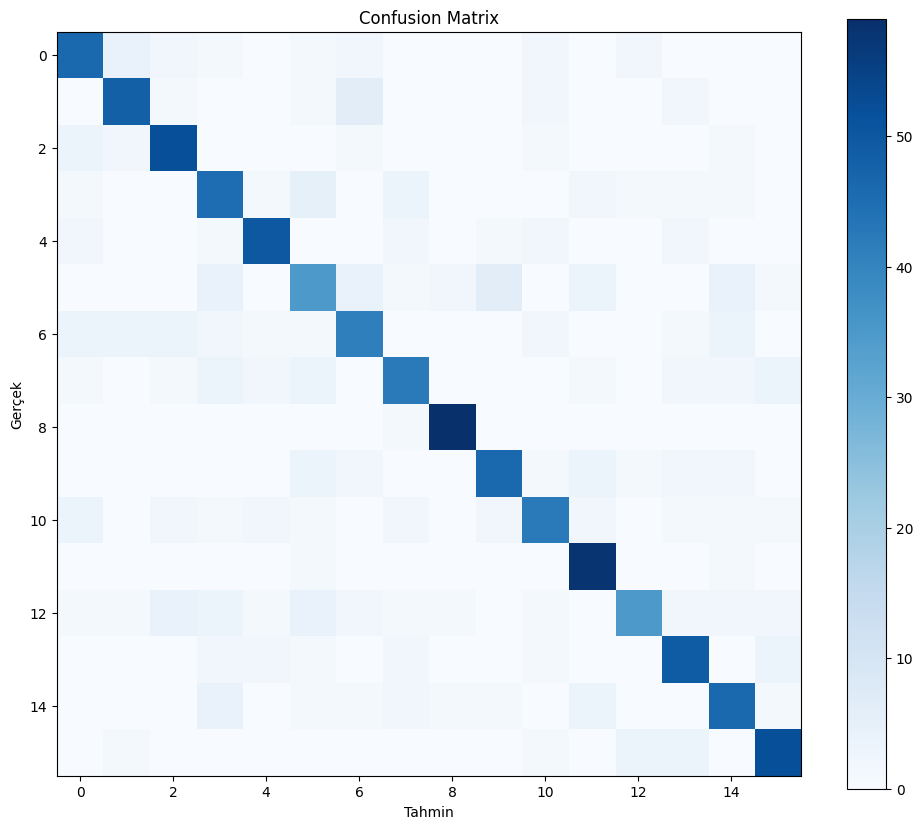

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        60
           1       0.81      0.80      0.81        60
           2       0.80      0.87      0.83        60
           3       0.68      0.75      0.71        60
           4       0.85      0.83      0.84        60
           5       0.61      0.58      0.60        60
           6       0.69      0.68      0.69        60
           7       0.75      0.70      0.72        60
           8       0.94      0.98      0.96        60
           9       0.82      0.77      0.79        60
          10       0.76      0.70      0.73        60
          11       0.81      0.97      0.88        60
          12       0.83      0.58      0.69        60
          13       0.75      0.82      0.78        60
          14       0.73      0.77      0.75        60
          15       0.83      0.87      0.85        60

    accuracy                           0.78       960
   macro avg       0.78   

In [46]:
y_pred = np.argmax(model.predict(X_test), axis=1)

plt.figure(figsize=(12, 10))
plt.imshow(confusion_matrix(y_test, y_pred), cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

print(classification_report(y_test, y_pred))